In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class ModerationState(TypedDict):
    post_content: str
    user_reputation: str
    
    formatted_post: str
    content_flag: str
    result: str

In [3]:
def format_post(state: ModerationState):
    # Mirrors 'show_equation' from the original
    formatted = f"User ({state['user_reputation']}) says: {state['post_content']}"
    return {'formatted_post': formatted}

In [4]:
def analyze_content(state: ModerationState):
    content = state['post_content'].lower()
    
    # Simple mock logic for content moderation
    if 'spam' in content or 'buy now' in content:
        flag = 'rejected'
    elif state['user_reputation'] == 'new_user':
        flag = 'review'
    else:
        flag = 'approved'
        
    return {'content_flag': flag}

In [5]:
def approve_post(state: ModerationState):
    result = 'Post published successfully to the timeline.'
    return {'result': result}

In [6]:

def flag_for_review(state: ModerationState):
    result = 'Post sent to the human moderation queue.'
    return {'result': result}

In [7]:
def reject_post(state: ModerationState):
    result = 'Post automatically deleted due to policy violation.'
    return {'result': result}

In [8]:
def check_condition(state: ModerationState) -> Literal["approve_post", "flag_for_review", "reject_post"]:
    if state['content_flag'] == 'approved':
        return "approve_post"
    elif state['content_flag'] == 'review':
        return "flag_for_review"
    else:
        return "reject_post"

In [9]:
graph = StateGraph(ModerationState)

# add the nodes
graph.add_node('format_post', format_post)
graph.add_node('analyze_content', analyze_content)
graph.add_node('approve_post', approve_post)
graph.add_node('flag_for_review', flag_for_review)
graph.add_node('reject_post', reject_post)


# add the edges
graph.add_edge(START, 'format_post')
graph.add_edge('format_post', 'analyze_content')

# Add conditional edges
graph.add_conditional_edges('analyze_content', check_condition)

# Connect all branches to END
graph.add_edge('approve_post', END)
graph.add_edge('flag_for_review', END)
graph.add_edge('reject_post', END)

workflow = graph.compile()

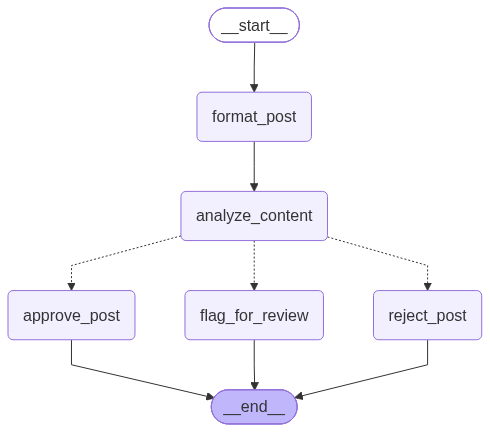

In [10]:
workflow

In [11]:

initial_state = {
    'post_content': "Check out this amazing new product!", 
    'user_reputation': "new_user"
}

result = workflow.invoke(initial_state)

In [12]:
result

{'post_content': 'Check out this amazing new product!',
 'user_reputation': 'new_user',
 'formatted_post': 'User (new_user) says: Check out this amazing new product!',
 'content_flag': 'review',
 'result': 'Post sent to the human moderation queue.'}